# Compressive Strength of Concrete

<a target="_blank" href="https://colab.research.google.com/github/LuisAngelMendozaVelasco/luisangelmendozavelasco.github.io/blob/master/_portfolio/IBM_AI_Engineering/portfolio-12.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>

**Objective**: Train a basic Neural Network (NN) for regression to predict the compressive strength of concrete.

## Import libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from keras import Sequential, Input, layers, callbacks
from sklearn.metrics import mean_squared_error, r2_score
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

2025-06-19 02:03:52.733997: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750320232.753052  386059 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750320232.758044  386059 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## Load the dataset

In [2]:
file_url = 'https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DL0101EN/labs/data/concrete_data.csv'
df = pd.read_csv(file_url)
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


## Understand the dataset

The dataset is about the compressive strength of different samples of concrete based on the volumes of the different ingredients that were used to make them. Ingredients include:

1. Cement
2. Blast Furnace Slag
3. Fly Ash
4. Water
5. Superplasticizer
6. Coarse Aggregate
7. Fine Aggregate

So the first concrete sample has 540 m³ of cement, 0 m³ of blast furnace slag, 0 m³ of fly ash, 162 m³ of water, 2.5 m³ of superplaticizer, 1040 m³ of coarse aggregate, and 676 m³ of fine aggregate. Such a concrete mix which is 28 days old, has a compressive strength of 79.99 MPa.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cement              1030 non-null   float64
 1   Blast Furnace Slag  1030 non-null   float64
 2   Fly Ash             1030 non-null   float64
 3   Water               1030 non-null   float64
 4   Superplasticizer    1030 non-null   float64
 5   Coarse Aggregate    1030 non-null   float64
 6   Fine Aggregate      1030 non-null   float64
 7   Age                 1030 non-null   int64  
 8   Strength            1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


## Visualize the dataset

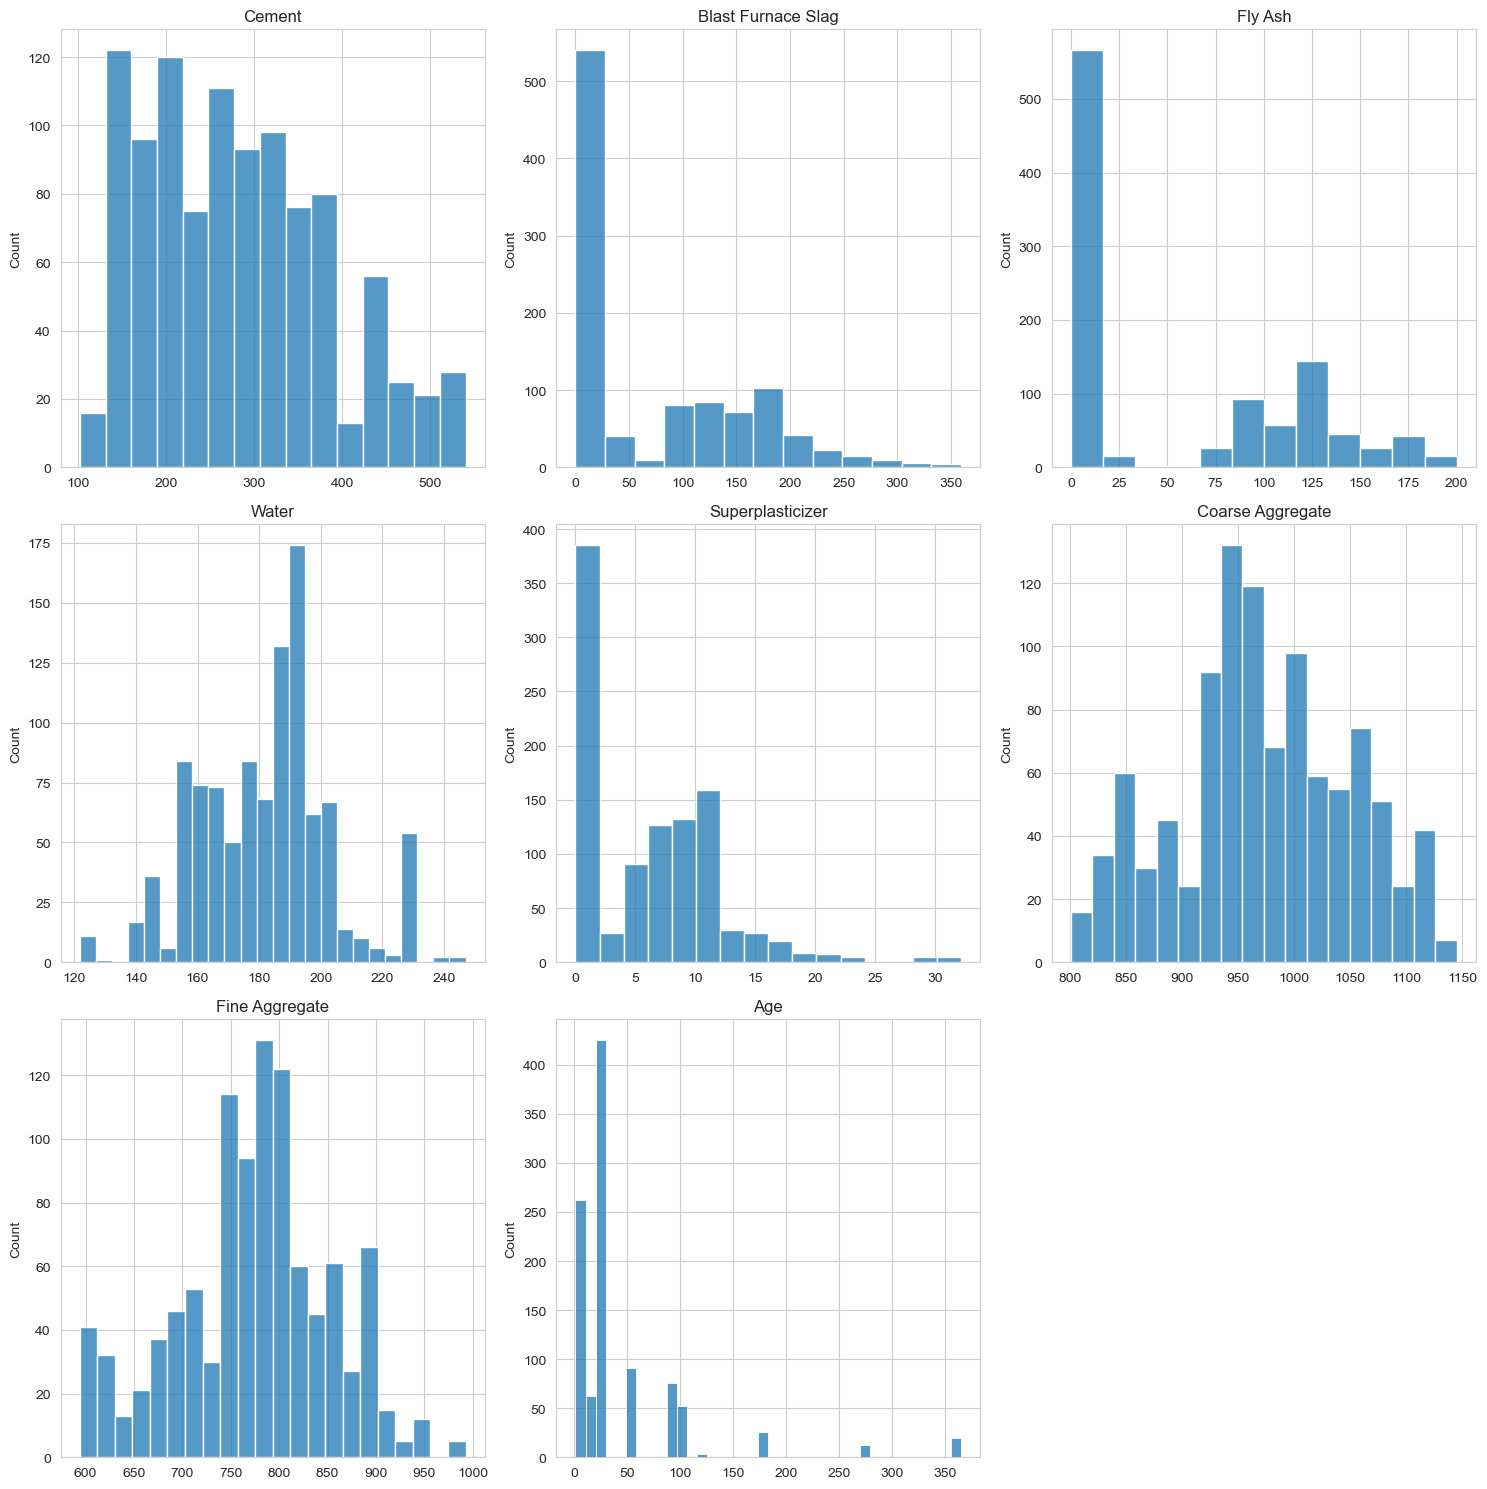

In [4]:
number_features = len(df.columns) - 1
grid_rows = int(np.ceil(number_features / 3))
fig, axs = plt.subplots(grid_rows, 3, figsize=(15, 5 * grid_rows))

for ax, feature in zip(axs.flatten(), df.columns[:-1]):
    if len(df[feature].unique()) <= 10:
        labels, sizes = np.unique(df[feature], return_counts=True)
        sns.barplot(x=labels, y=sizes, hue=labels, ax=ax, palette="tab10", legend=False)
        ax.set_xlabel("")
        ax.set_title(feature)
    else:
        sns.histplot(data=df, x=feature, ax=ax)
        ax.set_xlabel("")
        ax.set_title(feature)

for ax in axs.flatten()[number_features:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Visualize the target feature

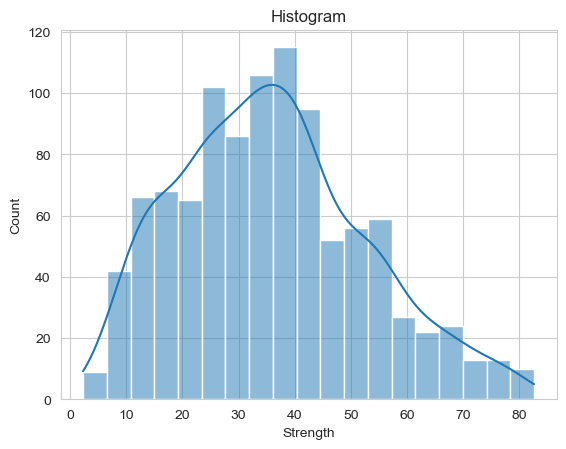

In [5]:
plt.figure()
sns.histplot(data=df, x="Strength", kde=True)
plt.title("Histogram")
plt.show()

## Preprocess the dataset

In [6]:
X = df.drop("Strength", axis=1)
y = df["Strength"]

scaler = StandardScaler()
X = scaler.fit_transform(X)
X = pd.DataFrame(X, columns=df.columns[:-1])
X.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,2.477915,-0.856888,-0.847144,-0.916764,-0.620448,0.863154,-1.217670,-0.279733
1,2.477915,-0.856888,-0.847144,-0.916764,-0.620448,1.056164,-1.217670,-0.279733
2,0.491425,0.795526,-0.847144,2.175461,-1.039143,-0.526517,-2.240917,3.553066
3,0.491425,0.795526,-0.847144,2.175461,-1.039143,-0.526517,-2.240917,5.057677
4,-0.790459,0.678408,-0.847144,0.488793,-1.039143,0.070527,0.647884,4.978487


## Split the dataset into train, validation and test subsets

In [7]:
X_train, X_right, y_train, y_right = train_test_split(X, y, train_size=0.8, random_state=0)
X_validation, X_test, y_validation, y_test = train_test_split(X_right, y_right, train_size=0.5, random_state=0)

print("X_train shape:", X_train.shape)
print("X_validation shape:", X_validation.shape)
print("X_test shape:", X_validation.shape)

X_train shape: (824, 8)
X_validation shape: (103, 8)
X_test shape: (103, 8)


## Define a custom callback

In [8]:
class CustomVerbose(callbacks.Callback):
    def __init__(self, epochs_to_show):
        self.epochs_to_show = epochs_to_show

    def on_epoch_begin(self, epoch, logs=None):
        if epoch in self.epochs_to_show:
            self.epoch_start_time = datetime.now()

    def on_epoch_end(self, epoch, logs=None):
        if epoch in self.epochs_to_show:
            self.epoch_stop_time = datetime.now()
            print(f"Epoch {epoch + 1}/{self.epochs_to_show[-1] + 1}")
            print(f"\telapsed time: {(self.epoch_stop_time - self.epoch_start_time).total_seconds():.3f}s - r2_score: {logs['r2_score']:.4f} - loss: {logs['loss']:.4f} - val_r2_score: {logs['val_r2_score']:.4f} - val_loss: {logs['val_loss']:.4f}")

## Build a NN

In [9]:
model = Sequential()
model.add(Input(shape=(X.shape[1],)))
model.add(layers.Dense(50, activation="relu"))
model.add(layers.Dense(50, activation="relu"))
model.add(layers.Dense(1))

model.summary()

I0000 00:00:1750320237.112416  386059 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1548 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 50)             │           450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,051 (11.92 KB)

 Trainable params: 3,051 (11.92 KB)

 Non-trainable params: 0 (0.00 B)

## Compile and train the NN

In [10]:
model.compile(optimizer="adam", loss='mean_squared_error', metrics=['r2_score'])

epochs = 500
patience = int(epochs / 10)
epochs_to_show = [0] + [i for i in range(patience - 1, epochs, patience)]
custom_verbose = CustomVerbose(epochs_to_show)
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=patience, verbose=1)
history = model.fit(x=X_train, y=y_train, epochs=epochs, verbose=0, validation_data=(X_validation, y_validation), callbacks=[custom_verbose, early_stopping])

I0000 00:00:1750320238.648838  386163 service.cc:148] XLA service 0x7ff640003a90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1750320238.648855  386163 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce GTX 1650, Compute Capability 7.5
2025-06-19 02:03:58.665817: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1750320238.744723  386163 cuda_dnn.cc:529] Loaded cuDNN version 91001
I0000 00:00:1750320239.348321  386163 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Epoch 1/500
	elapsed time: 3.216s - r2_score: -4.3962 - loss: 1523.1836 - val_r2_score: -4.3241 - val_loss: 1317.8010
Epoch 50/500
	elapsed time: 0.136s - r2_score: 0.6725 - loss: 92.4338 - val_r2_score: 0.6299 - val_loss: 91.6155
Epoch 100/500
	elapsed time: 0.109s - r2_score: 0.8769 - loss: 34.7378 - val_r2_score: 0.8670 - val_loss: 32.9278
Epoch 150/500
	elapsed time: 0.101s - r2_score: 0.9078 - loss: 26.0273 - val_r2_score: 0.8877 - val_loss: 27.7951
Epoch 200/500
	elapsed time: 0.109s - r2_score: 0.9250 - loss: 21.1755 - val_r2_score: 0.8969 - val_loss: 25.5151
Epoch 250/500
	elapsed time: 0.119s - r2_score: 0.9388 - loss: 17.2768 - val_r2_score: 0.9062 - val_loss: 23.2164
Epoch 300/500
	elapsed time: 0.105s - r2_score: 0.9466 - loss: 15.0770 - val_r2_score: 0.9072 - val_loss: 22.9700
Epoch 350/500
	elapsed time: 0.111s - r2_score: 0.9503 - loss: 14.0427 - val_r2_score: 0.9062 - val_loss: 23.2286
Epoch 354: early stopping


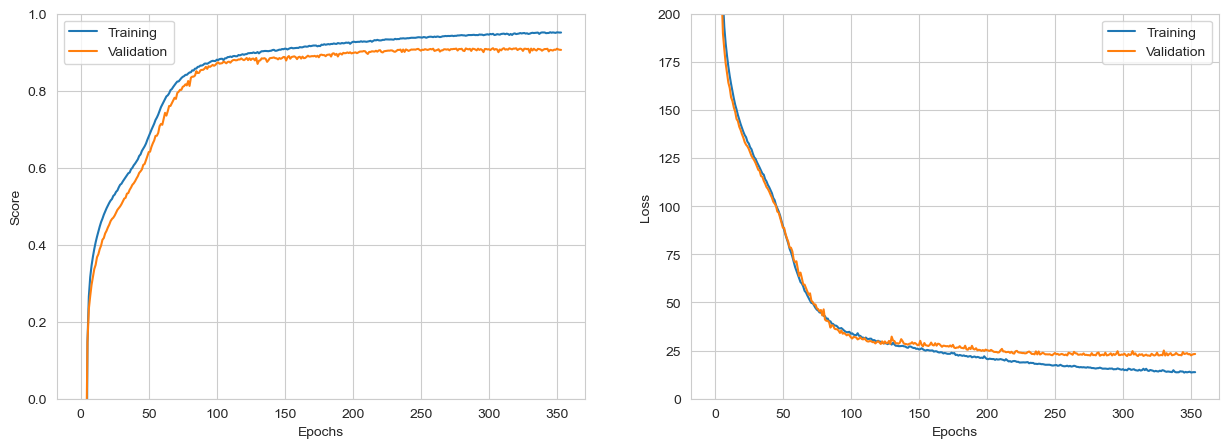

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(history.history['r2_score'])
ax1.plot(history.history['val_r2_score'])
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Score")
ax1.legend(["Training", "Validation"])
ax1.set_ylim(0, 1)

ax2.plot(history.history['loss'])
ax2.plot(history.history['val_loss'])
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Loss")
ax2.legend(["Training", "Validation"])
ax2.set_ylim(0, 200)

plt.show()

## Evaluate the NN

In [12]:
y_pred = model.predict(X_test, verbose=0)

print(f"MSE = {mean_squared_error(y_test, y_pred):.2f}")
print(f"R² = {r2_score(y_test, y_pred):.2f}")

MSE = 31.25
R² = 0.89
